# Optimal Test Design
Este notebook é a continuação do notebook "Curvas de Informação". Lá, investigamos por meio das curvas de informação das provas históricas do ENEM se seria possível usar estas provas tanto para fins de seleção de indivíduos, como para fins de avaliação sistêmica. Para atender as duas finalidades simultaneamente, as provas teriam que dar *informação* sobre individuos no intervalo inteiro de proficiência, desde abaixo da média, até bem acima da média. 

As provas atuais do ENEM, de propósito, têm um pico na curva de informação (dão mais informação) por volta de 700 pontos, ou dois desvios padrão acima da média. É possível desenhar um novo ENEM que fornece informação também por volta de 400 pontos (1 desvio padrão abaixo da média)?

Um especialista em avaliação me disse uma vez (parafraseando)
> "O INEP simplesmente vai inserir alguns itens fáceis"

Mas não é nada óbvio que é tão simples assim. No outro notebook vimos que forçando a inserção de itens fáceis de fato pode mudar a curva de informação das provas. Mas amostrar aleatoriamente itens de um banco de itens (mesmo forçando alguns itens ser fáceis) pode não ser a forma otimal de desenhar uma prova. Existe uma metodologia menos *ad hoc* de escolher itens de um banco, dado certos critérios e um objetivo para otimizar.

No nosso caso, o objetivo seria uma curva de informação do teste achatada entre $-1 > \theta > 2$ e maior do que uma determinada valor mínimo. Os critérios (ou restrições ou condições de contorno) seriam, por exemplo, que o número de itens deve ser 45 e que é preciso pelo menos X itens de cada competência.

Se o seu banco de itens contém, digamos, 1700 itens, o número de possível provas seria $2^{1700}$ e mesmo restringindo à provas de 45 itens, teríamos $\binom{1700}{45} = 108953404207351699016793209909860411156916569268404357140239792894822978684461839546154880$ combinações possíveis. Obviamente não dá para minimizar a função objetiva por força bruta. Mas, há algorítmos para isso! Uma área inteira de matemática é sobre otimização e vamos usar uma sub-área disso chamado "Linear Programming" ou "mixed-integer programming". Existe software especializado, mas nós por agora vamos usar os algoritmos que vem com [Scipy](https://docs.scipy.org/doc/scipy/reference/optimize.html#linear-programming-milp).

As referências que vamos seguir são:
 * LINDEN, Wim J. van der. Linear models of optimal test design. New York, NY: Springer, 2005. 
 * VAN DER LINDEN, Wim J. Optimal Test Design. In: VAN DER LINDEN, Wim J. (Org.). Handbook of item response theory. [S.l.]: CRC Press, Taylor & Francis Group, 2016. v. 3. 


In [5]:
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import matplotlib.pyplot as plt
import random

from scipy import optimize
from scipy.optimize import milp
from scipy.optimize import LinearConstraint

from util import (provas, params_inep, irt_params_to_enem_scale,item_info_inep, 
                  PL3, iteminfo, testinfo)

import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
# só para calcular o exemplo retórico acima
import math
math.comb(1700,45)

108953404207351699016793209909860411156916569268404357140239792894822978684461839546154880

## Funções para gerar itens
Vamos precisar algumas funções que fornecem os itens (seus parâmetros TRI) para o algoritmo de otimização usar. Um deles recupera simplesmente os itens históricos:

In [13]:
def item_bank(area=None,ano=None,remove_outliers = True):
    
    itens = item_info_inep(ano,area)
    itens = itens.drop_duplicates('CO_ITEM')
    itens = itens[itens['IN_ITEM_ABAN'] == 0]
    params = itens[["CO_ITEM","NU_PARAM_A","NU_PARAM_B","NU_PARAM_C","ano","SG_AREA"]]
    params = params.set_index("CO_ITEM")
    params.columns = ["a_inep","b_inep","c_inep","ano","area"]
    params.insert(3,'u',1)
    if remove_outliers:
        params = params.query("a_inep < 7 & b_inep < 10")
    return params

params = item_bank('LC',remove_outliers=True)
print(f"Total de itens entre 2009 e 2024 = {len(params)}\nVeja o número de itens, e a média / std para $a$ e $b$ por ano:")
params.groupby(['ano']).agg({'u':'count','a_inep':['mean','std'],'b_inep':['mean','std']})

Total de itens entre 2009 e 2024 = 1742
Veja o número de itens, e a média / std para $a$ e $b$ por ano:


u    a_inep              b_inep          
     count      mean       std      mean       std
ano                                               
2009    89  1.536481  0.508112  0.814520  0.923649
2010    95  2.141005  0.803760  0.350133  0.776366
2011    97  2.375568  1.017648  0.524892  0.564129
2012   145  1.879890  0.613721  0.749234  0.680803
2013   100  1.905316  0.770765  0.615243  0.851861
2014   114  2.414606  0.929331  0.834674  0.814642
2015   103  2.381663  0.925354  0.874700  1.056080
2016    97  2.154542  0.843405  0.936211  0.796311
2017   143  2.497627  0.813774  0.499696  0.585702
2018   100  2.224261  0.897342  0.967352  0.719275
2019    99  2.580612  1.025489  0.789562  0.583356
2020   149  2.083053  0.819634  0.956577  0.855301
2021   105  2.124164  0.760970  0.767502  0.786825
2022   104  1.949620  0.781248  0.764427  0.771227
2023   102  2.028382  0.647969  0.679425  0.694070
2024   100  2.340944  1.030042  0.695996  0.702082

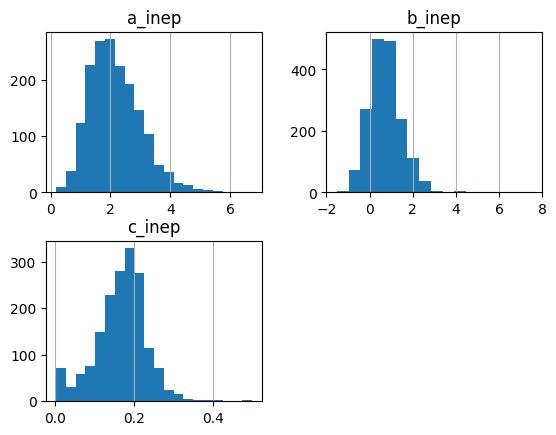

In [15]:
params = item_bank(area='LC')
axs = params.hist(column=['a_inep','b_inep','c_inep'],bins=20);
axs[0,1].set_xlim(-2,8)
for ax in axs.flatten():
    ax.grid(axis='y')

## Otimizando a CI num único $\theta$

Antes de mais nada, vamos implementar o caso mais simples: otimizar uma curva de informação para que num determinado $\theta_c$ o valor da informação é máxima. Formalmente:

$$
\mathrm{maximizar} \sum_{i=1}^{N_b} I_i(\theta_c) x_i
$$
sujeito a 
$$
 \sum_{i=1}^{N_b} x_i = 45
$$
e os varáveis de decisão $x_i \in {0,1}$ são 0 ou 1 e $i$ varia sobre todos os itens do banco de itens. 
Note que podemos somar as informações de item $I_i$ sobre todos os itens do banco, porque os itens com $x_i = 0$ não contribuam na soma.

O problema acima é *linear* com respeito às variáveis de decisão $x_i$, tanto para o objetivo, como para as restrições. Para resolver, vamos usar a função `milp` de `scipy.optimize`. A função requer que um array `values` que, multiplicado com $\vec{x}$, vai dar o objetivo a optimizar (minimizar, no caso do `milp`).

Para o problema acima, vamos, portanto, calcular $I_i(\theta_c)$ com $\theta_c$ o valor para qual a informação do teste deve ser máxima, sujeito à restrição que só podemos usar 45 itens.

In [16]:
items = item_bank(area='MT')
theta_c = 2
values = [iteminfo(theta_c,item['a_inep'],item['b_inep'],item['c_inep']) for i,item in items.iterrows()]
values = np.array(values)
print(len(values))
values # um array com aprox. 1700 valores

1603


array([0.68575806, 1.09439051, 2.17962088, ..., 0.26747389, 0.59579343,
       0.44338805])

A função `milp` tem argumentos `bounds` e `integrality` para restringir os variáveis de decisão $x_i$. As próximas duas linhas dizem que $x_i \in {0,1}$

In [17]:
bounds = optimize.Bounds(0, 1)  # 0 <= x_i <= 1
integrality = np.full_like(values, True)  # x_i are integers

In [18]:
integrality

array([1., 1., 1., ..., 1., 1., 1.])

A restrições neste caso são muito simples: o total do teste deve ser 45 itens. Note que podíamos ter usado `lb = 0` (lower bound = 0). Tanto faz, porque a informação sempre cresce com mais um item.

In [19]:
constraints = optimize.LinearConstraint(A=np.ones(len(values)), lb=45, ub= 45)
res = milp(c=-values,  # note que milp sempre minimiza e por isso o sinal menos.
           bounds=bounds,
           integrality=integrality,
           constraints=constraints)
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -102.71713546321799
              x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
 mip_node_count: 1
 mip_dual_bound: -102.71713546321799
        mip_gap: 0.0

A temos a solução em res.x. Usamos `items[res.x.astype(bool)]` para extrair os itens que o algoritmo achou. De fato, comparado com uma amostra aleatória a curva de informação está bem mais alta no valor de $\theta_c$ desejado.

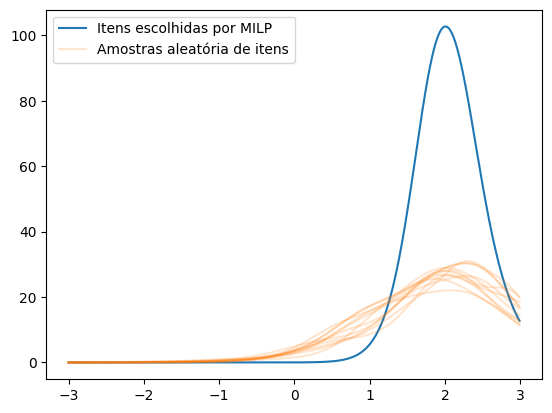

In [22]:
optitems = items[res.x.astype(bool)]
thetas = np.arange(-3,3,0.01)
I = testinfo(thetas,optitems)
plt.plot(thetas,I,label="Itens escolhidas por MILP")
for i in range(10):
    In = testinfo(thetas,items.sample(45))
    plt.plot(thetas,In,alpha=0.2,color='C1')

plt.plot(thetas,In,label="Amostras aleatória de itens",alpha=0.2)
plt.legend()

## Otimizando a CI em várias $\theta$s

O segundo exemplo é só um pouco mais complexo. Agora, ao invés de só controlar (maximizar) a informação do teste num único $\theta_c$, vamos especificar alguns ($K$) pontos de controle $\theta_k$ onde vamos especificar um valor mínimo da informação $I_k$. Formalmente:

$$
\text{minimizar} \sum_{k=1}^{K} \sum_{i=1}^{N_b} I_i(\theta_k) x_i
$$
sujeito a
$$
\sum_{i=1}^{N_b} I_i(\theta_k) x_i > T_k, \ \text{para todos os}\ k.
$$ 

e

$$
\sum_{i=1}^{N_b} I_i(\theta_k) x_i < T_k + \delta, \ \text{para todos os}\ k.
$$

para algum $\delta$ que define a faixa de informação permitido. Ou seja, estamos restrigindo a informação entre $T_k$ e $T_k + \delta$. 

Note que estamos agora *minimizando* a informação e a restrição faz a curva de informação se aproximar aos $K$ pontos de controle. Veja como implementar isso usando `scipy.milp`:

In [23]:
items = item_bank(area='LC')

CPU times: user 1.48 s, sys: 4.69 ms, total: 1.49 s
Wall time: 1.35 s
45
        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -24.999730674681064
              x: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
 mip_node_count: 1
 mip_dual_bound: -24.999999999669544
        mip_gap: 1.0773115598110967e-05


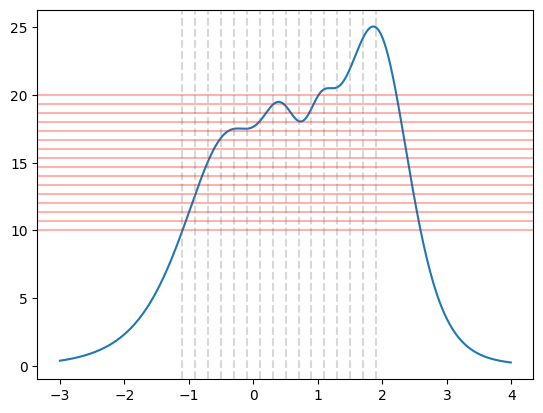

In [24]:
#theta_k = [-0.5,0,0.5,1,1.5,2]     # os thetas de controle
theta_k = np.arange(-1.1,2,0.2)  # queremos controlar a curva de informação entre 0 < theta < 2 
values = []
# para cada item no banco (aprox.1700 deles) somamos sobre k a informação I(theta_k)
for i,item in items.iterrows():
    value = 0
    for theta in theta_k:
        value =+ iteminfo(theta,item['a_inep'],item['b_inep'],item['c_inep'])
    values.append(value)
values = np.array(values)

# os variáveis de decisão x_i são 0 ou 1
bounds = optimize.Bounds(0, 1)  # 0 <= x_i <= 1
integrality = np.full_like(values, True)  # x_i are integers

# A restrição é que a informação nos thetas de controle devem ser entre determinados valores
# Este restrição é implementado via o matriz A com 
# k linhas (número de pontos de controle) e i colunas (tamanho do banco)
# A função LinearConstraint fará que lb < A dot x < ub com lb (lower bound) e ub
# (upper bound) vetores de k valores.

A = np.zeros((len(theta_k),len(values)))
for i,theta in enumerate(theta_k):
    A[i,:] = [iteminfo(theta,item['a_inep'],item['b_inep'],item['c_inep']) for j,item in items.iterrows()]

I_lb = np.linspace(10,20,len(theta_k))  # só para ver se funciona

diff = 5
constraint1 = optimize.LinearConstraint(A=A, lb=I_lb, ub=I_lb+diff)
#constraint1 = optimize.LinearConstraint(A=A, lb=I_lb)

# A última restrição é que queremos um teste com exatamente 45 itens
constraint3 = optimize.LinearConstraint(A=np.ones(len(values)), lb=45, ub= 45)

# vamos trabalhar...
%time res = milp(c=-values,constraints=[constraint1,constraint3],integrality=integrality,bounds=bounds)

if res.success:
    optitems = items[res.x.astype(bool)]
    thetas = np.arange(-3,4,0.01)
    I = testinfo(thetas,optitems)
    plt.plot(thetas,I)
    ax = plt.gca()
    for theta,I in zip(theta_k,I_lb):
        ax.axvline(theta,ls='--',color='gray',alpha=0.3)
        ax.axhline(I,ls='-',color='red',alpha=0.3)
    print(len(optitems))
    print(res)
else:
    print(res.message)

## Uma função para "desenhar" curvas de informação
Vamos encapsular as células acima, para poder experimentar mais fácil.

In [62]:
def optimize_items(items, theta_k, I_k, delta=1, N = 1):
    
    theta_k = np.array(theta_k)
    I_k = np.array(I_k)
    
    results = []
    for n in range(N):
        print(f"round {n}, {len(items)} items left")
        values = []
        for i,item in items.iterrows():
            value = 0
            for theta in theta_k:
                value =+ iteminfo(theta,item['a_inep'],item['b_inep'],item['c_inep'])
            values.append(value)
        values = np.array(values)
        
        bounds = optimize.Bounds(0, 1)  # 0 <= x_i <= 1
        integrality = np.full_like(values, True)  # x_i are integers
            
        A = np.zeros((len(theta_k),len(values)))
        for i,theta in enumerate(theta_k):
            A[i,:] = [iteminfo(theta,item['a_inep'],item['b_inep'],item['c_inep']) for j,item in items.iterrows()]
        
        constraint1 = optimize.LinearConstraint(A=A, lb=I_k, ub=I_k+delta)
        constraint2 = optimize.LinearConstraint(A=np.ones(len(values)), lb=45, ub=45)
        
        # vamos trabalhar...
        
        res = %time milp(c=-values,constraints=[constraint1,constraint2],integrality=integrality,bounds=bounds)
        results.append(res)
        if not res.success:
            print(f"O problema de otimazação era impossível de resolver no round {n} e com {len(items)} itens sobrando!")
            break
            
        items = items[~res.x.astype(bool)]
    return results

def show_otimizations(results,items,theta_k,I_k):
    
    for res in results:
        if res.success:
            optitems = items[res.x.astype(bool)]
            thetas = np.arange(-2,4,0.01)
            I = testinfo(thetas,optitems)
            plt.plot(thetas,I)
            ax = plt.gca()
            for theta,I in zip(theta_k,I_k):
                ax.axvline(theta,ls='--',color='gray',alpha=0.3)
                ax.axhline(I,ls='-',color='red',alpha=0.3)
            print(len(optitems))
            items = items[~res.x.astype(bool)]
        else:
            return

Veja como usar esta função. Deve definir os itens que o algoritmo de otimização pode usar, usando por exemplo a função `item_bank`. `theta_k` e `I_k` são, respectivamente, as thetas de controle (onde vai definir a informação desejada) e a informação desejada. 

O `delta` determina o tamanho do intervalo permitido. Se deixar pequeno demais, o problema não vai ter resolução para nenhuma combinação de itens. Mas se deixar grande demais, vai ser ondulações não-desejadas na curva de informação. 

Finalmente, o `N` implementa uma simulação onde tem várias rodadas, *tirando* os itens anteriores, para ter uma ideia de quanto estamos "esgotando" o banco de itens. As rodadas terminam quando o problema não tem mais solução. 

In [73]:
np.array([20.1,10,10,15,20] ).dtype

dtype('float64')

round 0, 1603 items left
CPU times: user 29.4 s, sys: 4.07 s, total: 33.5 s
Wall time: 28 s
45


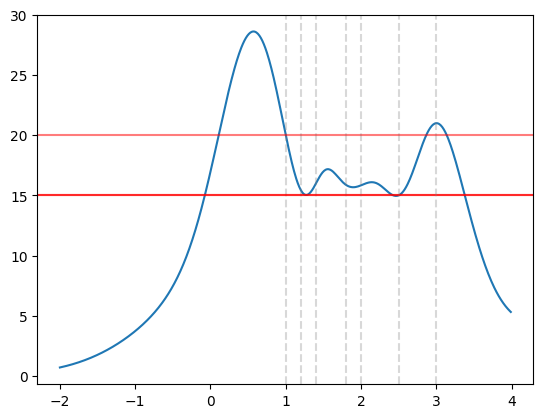

In [82]:
items = item_bank('MT')
# o jeito mais manual de definir os pontos de controle
theta_k = [1,1.2,1.4,1.8,2,2.5,3]    # os thetas de controle
I_k = [20,15,15,15,15,15,20]      # uma curva "U", dando mais informação em theta = 0 e theta = 2 

results = optimize_items(items,theta_k,I_k)
show_otimizations(results,items,theta_k,I_k)

In [60]:

theta_k = np.arange(1,2,0.2)
I_k  = np.linspace(30,30,len(theta_k)) 
items = item_bank(area='MT')

results = optimize_items(items,theta_k,I_k,delta=0.5,N=10)

round 0, 1603 items left
CPU times: user 1.72 s, sys: 151 ms, total: 1.87 s
Wall time: 1.65 s
round 1, 1558 items left
CPU times: user 2.75 s, sys: 566 ms, total: 3.32 s
Wall time: 2.77 s
round 2, 1513 items left
CPU times: user 2.22 s, sys: 333 ms, total: 2.55 s
Wall time: 2.07 s
round 3, 1468 items left
CPU times: user 5.25 s, sys: 856 ms, total: 6.1 s
Wall time: 5.09 s
round 4, 1423 items left
CPU times: user 1.81 s, sys: 249 ms, total: 2.06 s
Wall time: 1.7 s
round 5, 1378 items left
CPU times: user 9.18 s, sys: 1.06 s, total: 10.2 s
Wall time: 9.28 s
round 6, 1332 items left
CPU times: user 52.9 ms, sys: 7.25 ms, total: 60.2 ms
Wall time: 46.3 ms
O problema de otimazação era impossível de resolver no round 6 e com 1332 itens sobrando!


45
45
45
45
45
46


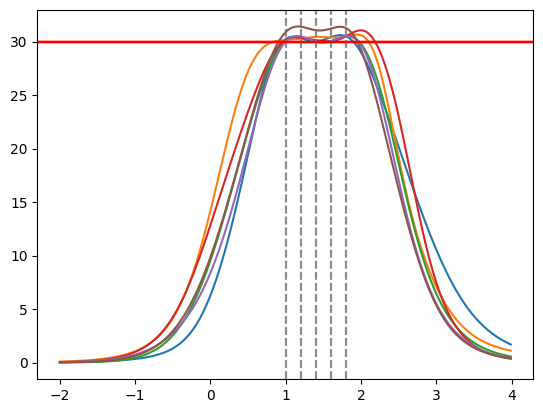

In [63]:
show_otimizations(results,items,theta_k, I_k)